# Single cell enrichment analysis tutorial
https://decoupler.readthedocs.io/en/latest/notebooks/scell/rna_sc.html#

In this notebook, let's infer transcription factor and pathway enrichment scores from a scRNA-seq dataset (the commonly used 3k PBMCs).

In [44]:
import scanpy as sc
import decoupler as dc

sc.set_figure_params(figsize=(5, 5), frameon=False)

## Loading the dataset

In [2]:
adata = dc.ds.pbmc3k()

In [4]:
adata.obs

,n_genes,percent_mito,n_counts,celltype,leiden
index,,,,,
AAACATACAACCAC-1,781,0.030178,2419.0,CD4 T cells,Clust:0
AAACATTGAGCTAC-1,1352,0.037936,4903.0,B cells,Clust:2
AAACATTGATCAGC-1,1131,0.008897,3147.0,CD4 T cells,Clust:0
AAACCGTGCTTCCG-1,960,0.017431,2639.0,CD14+ Monocytes,Clust:1
AAACCGTGTATGCG-1,522,0.012245,980.0,NK cells,Clust:4
...,...,...,...,...,...
TTTCGAACTCTCAT-1,1155,0.021104,3459.0,CD14+ Monocytes,Clust:1
TTTCTACTGAGGCA-1,1227,0.009294,3443.0,B cells,Clust:2
TTTCTACTTCCTCG-1,622,0.021971,1684.0,B cells,Clust:2


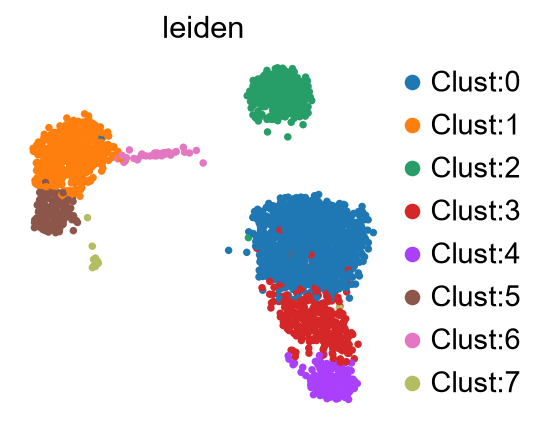

In [5]:
sc.pl.umap(adata, color='leiden')

## Cell type scoring using marker genes

Here, we'll use pre-defined sets of marker genes from PanglaoDB, which is a database with marker annotations across different tissue types.

Several enrichment score methods are available. This tutorial uses the univariate linear model (the highest performing method in benchmarking, according to the original `decoupler` paper.

In [25]:
markers = dc.op.resource("PanglaoDB", organism="human")

In [26]:
markers

,genesymbol,canonical_marker,cell_type,germ_layer,human,human_sensitivity,human_specificity,mouse,mouse_sensitivity,mouse_specificity,ncbi_tax_id,organ,ubiquitiousness
,,,,,,,,,,,,,
0,A1CF,False,Hepatocytes,Endoderm,True,0.189189,0.004437,True,0.175000,0.000257,9606,Liver,0.002
1,A2APA5,False,Germ cells,Mesoderm,False,0.000000,0.000000,True,0.432927,0.000000,10090,Reproductive,0.004
2,A2M,True,Bergmann glia,Ectoderm,True,0.000000,0.062343,True,0.333333,0.001604,9606,Brain,0.012
3,A3FIN4,False,Mast cells,Mesoderm,False,0.000000,0.000000,True,0.184211,0.000708,10090,Immune system,0.001
4,A4GALT,True,Mast cells,Mesoderm,True,0.000000,0.014133,True,0.000000,0.003023,9606,Immune system,0.005
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8206,ZNF521,False,Adipocyte progenitor cells,Mesoderm,True,0.000000,0.010338,False,0.000000,0.000000,9606,Connective tissue,0.002
8207,ZNRF4,False,Germ cells,Mesoderm,True,0.284360,0.000000,True,0.000000,0.000000,9606,Reproductive,0.010
8208,ZPBP2,True,Germ cells,Mesoderm,True,0.436019,0.000000,True,0.000000,0.000000,9606,Reproductive,0.008


At least with PanglaoDB, while there are thousands of annotated marker genes, we can be more selective about their use in our analysis. Let's use only canonical marker genes that have `human=True` and have a sensitivity of more than 0.5

In [27]:
markers = markers[
    (markers['human'] == True) &
    (markers['canonical_marker'] == True) &
    (markers['human_sensitivity'].astype(float) > 0.5)
]

In [32]:
# There seems to be 1 duplicate gene symbol + cell type pair. Let's remove it
markers = markers[~markers.duplicated(['genesymbol', 'cell_type'])]

# we only need gene symbol and cell type information, so let's format the table as such
markers = markers.loc[:, ['cell_type', 'genesymbol']]
markers = markers.reset_index(drop=True)
markers = markers.rename(columns={'cell_type': 'source', 'genesymbol': 'target'})
markers

,source,target
0,Pulmonary alveolar type II cells,ABCA3
1,Enterocytes,ACSL5
2,Smooth muscle cells,ACTA2
3,Smooth muscle cells,ACTG2
4,Myoepithelial cells,ACTG2
...,...,...
685,Endothelial cells,VWF
686,Luminal epithelial cells,WFDC2
687,Ductal cells,WFDC2
688,Podocytes,WT1


Now let's score our cells

In [33]:
dc.mt.ulm(adata, net=markers, tmin=3)

In [34]:
adata.obsm['score_ulm']

,Acinar cells,Adipocytes,Alpha cells,B cells,B cells naive,Beta cells,Dendritic cells,Ductal cells,Endothelial cells,Enterocytes,...,Pancreatic stellate cells,Pericytes,Plasma cells,Plasmacytoid dendritic cells,Platelets,Podocytes,Proximal tubule cells,Pulmonary alveolar type II cells,Smooth muscle cells,T cells
index,,,,,,,,,,,,,,,,,,,,,
AAACATACAACCAC-1,-0.537482,0.880015,1.501143,4.869608,3.822776,1.850666,7.993952,-0.406252,-0.885910,-0.454221,...,-0.351811,1.501143,3.070459,0.325694,4.707824,-0.574614,-0.574614,-0.497593,-0.454221,13.437334
AAACATTGAGCTAC-1,-0.703904,-0.266765,0.907750,10.639314,12.676054,-0.460741,14.592025,2.193505,0.334841,0.217661,...,-0.460741,2.193505,6.653792,1.056778,3.699963,-0.752534,-0.752534,-0.651663,-0.594861,3.827107
AAACATTGATCAGC-1,-0.670857,0.775482,1.195078,3.379488,6.287648,-0.439111,7.469071,-0.507061,0.039009,-0.566934,...,-0.439111,2.715337,1.806525,-0.318529,6.199206,-0.717204,0.042273,-0.621069,-0.566934,15.211887
AAACCGTGCTTCCG-1,0.745949,2.143531,0.671311,8.120865,4.465337,0.910382,26.901402,1.338112,0.637100,-0.523795,...,-0.405698,0.671311,4.233656,0.420052,7.887647,0.143440,-0.662630,-0.573810,-0.523795,5.473293
AAACCGTGTATGCG-1,-0.465875,-0.556890,1.495823,2.115894,0.170480,-0.304941,15.537294,-0.352129,0.080442,-0.393707,...,-0.304941,-0.352129,0.703835,3.160296,6.316497,-0.498060,-0.498060,-0.431300,-0.393707,3.873352
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTCGAACTCTCAT-1,1.305709,1.491715,1.096136,7.689370,3.972790,-0.441093,26.218950,2.529991,1.293456,-0.569493,...,-0.441093,2.702240,4.672744,1.096436,5.488147,-0.720441,-0.720441,-0.623872,-0.569493,5.171710
TTTCTACTGAGGCA-1,-0.697048,-0.833229,1.081317,9.558244,5.570785,-0.456254,12.581891,2.096218,-0.217294,-0.589067,...,-0.456254,2.984098,13.259767,2.046399,5.558045,-0.745205,-0.745205,-0.645316,-0.589067,2.361846
TTTCTACTTCCTCG-1,-0.491603,-0.587644,1.020571,15.879073,15.877780,-0.321781,17.799659,-0.371575,-0.810287,-0.415449,...,-0.321781,-0.371575,8.865448,1.326769,4.018225,-0.525565,-0.525565,-0.455119,-0.415449,4.885653


In [36]:
adata.layers['counts'] = adata.X

### Plotting and interpretting the enrichment scores

We can reuse many of Scanpy's plotting functions to plot enrichment scores themselves, but remember that anndata 'counts' are stored in `adata.X`. This means we have to extract our enrichment scores (which are stored in our current `adata.obsm['score_ulm']`) into their own anndata object.

In [39]:
scores_adata = dc.pp.get_obsm(adata, key="score_ulm")
scores_adata

AnnData object with n_obs × n_vars = 2638 × 36
    obs: 'n_genes', 'percent_mito', 'n_counts', 'celltype', 'leiden'
    uns: 'draw_graph', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'rank_genes_groups', 'leiden_colors'
    obsm: 'X_pca', 'X_tsne', 'X_umap', 'X_draw_graph_fr', 'score_ulm', 'padj_ulm'
    layers: None (.X)

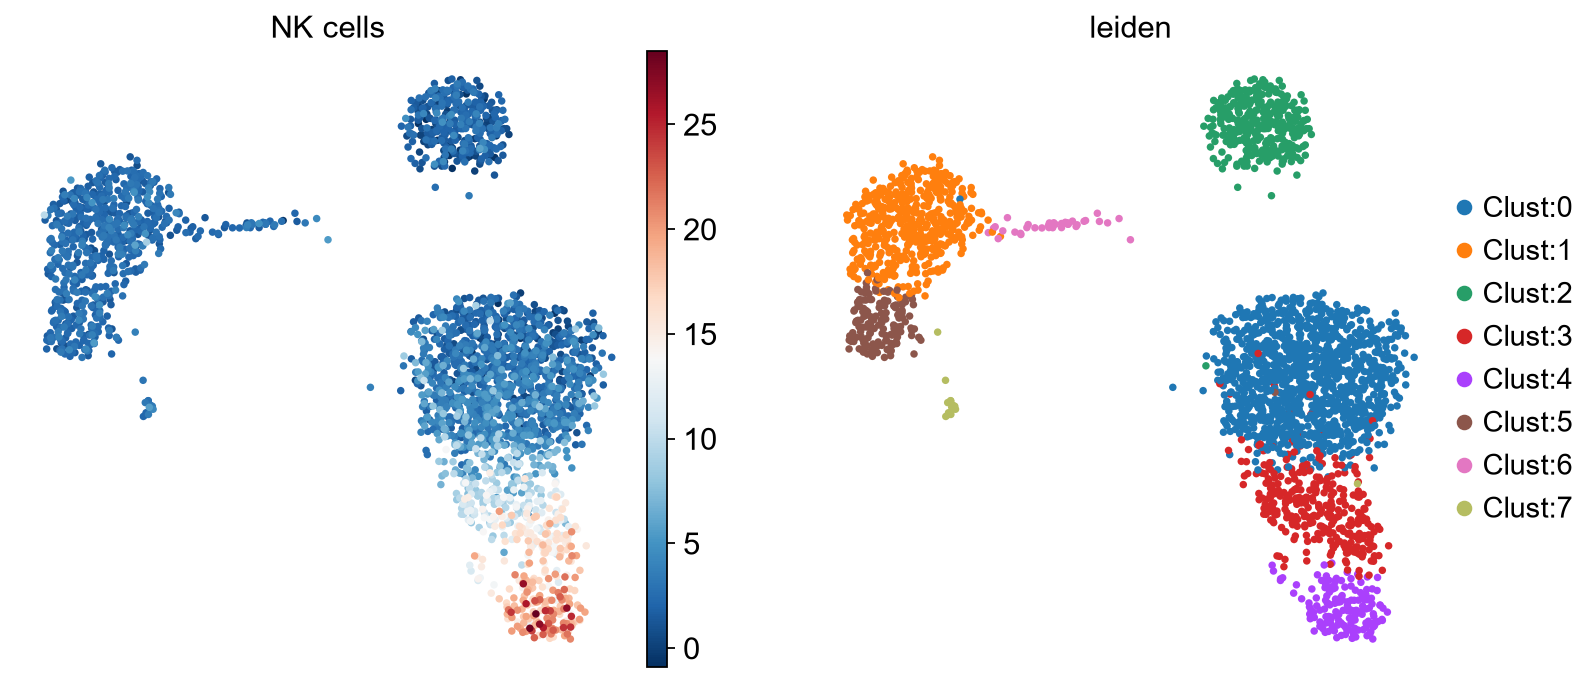

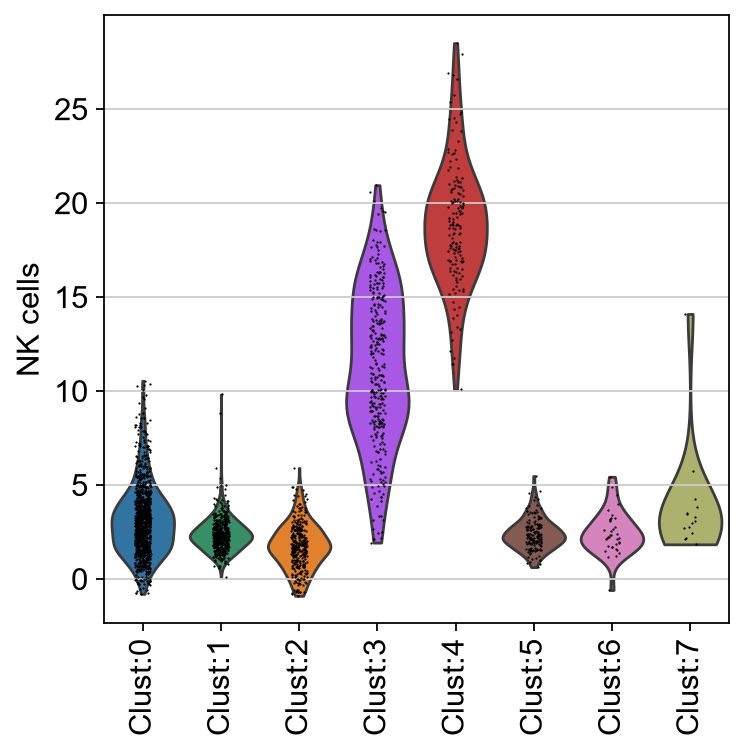

In [48]:
# NK cells
sc.pl.umap(scores_adata, color=['NK cells', 'leiden'], cmap='RdBu_r')
sc.pl.violin(scores_adata, keys=['NK cells'], groupby='leiden', rotation=90, dodge=False)

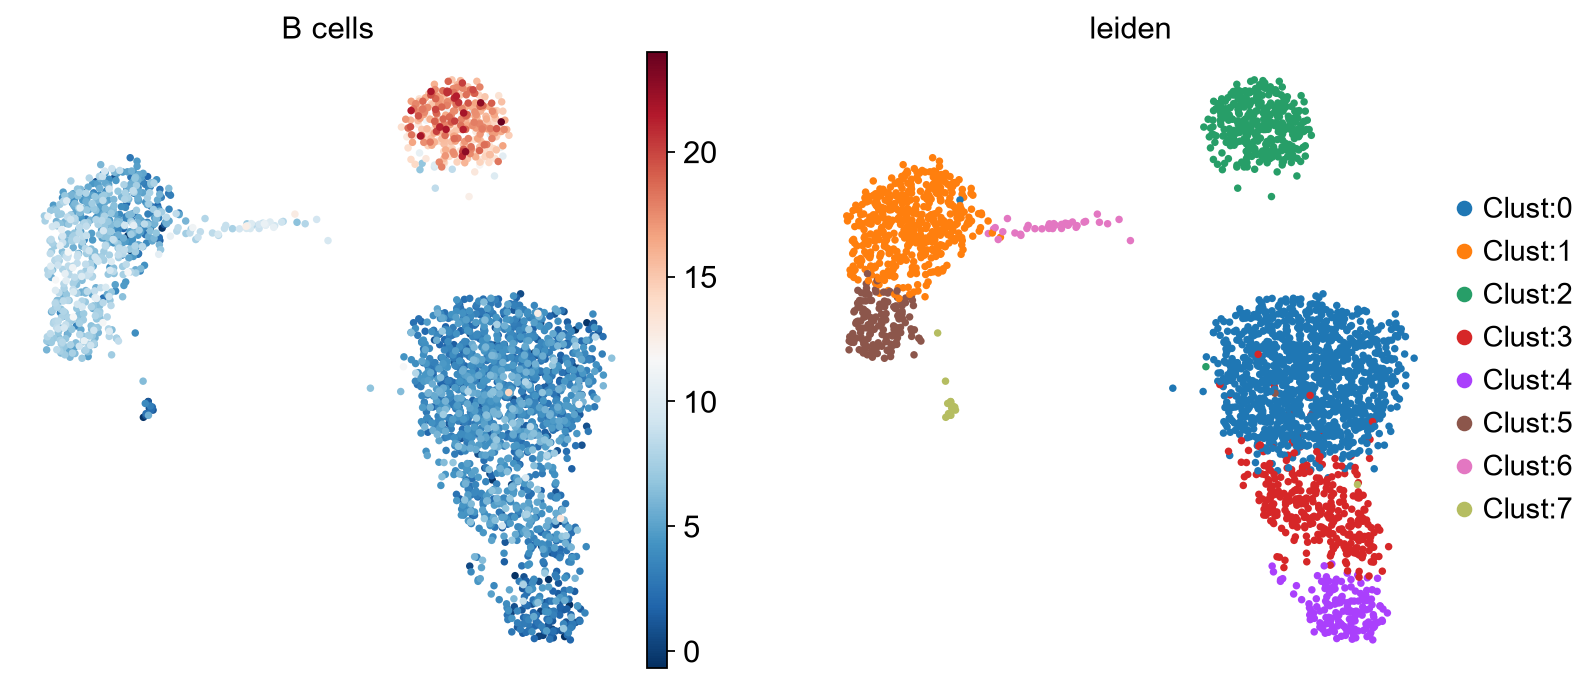

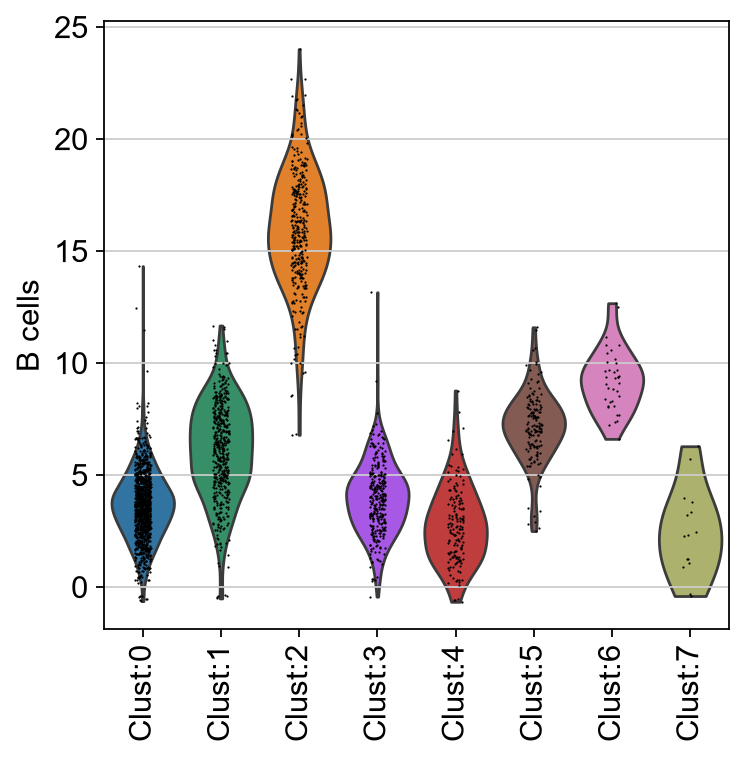

In [49]:
# B cells
sc.pl.umap(scores_adata, color=['B cells', 'leiden'], cmap='RdBu_r')
sc.pl.violin(scores_adata, keys=['B cells'], groupby='leiden', rotation=90, dodge=False)

We can even use similar statistical tests as scanpy's `tl.rank_genes_groups()` function to identify "marker" cell types per cluster! This works because our features in the `scores_adata` object are enrichment scores for each cell type.

In [50]:
df = dc.tl.rankby_group(scores_adata, groupby='leiden', reference='rest', method='wilcoxon')
df = df[df['stat'] > 0]
df

,group,reference,name,stat,meanchange,pval,padj
2,Clust:0,rest,T cells,32.337403,4.718293,2.085930e-229,2.503116e-228
14,Clust:0,rest,Erythroid-like and erythroid precursor cells,8.826911,0.211885,1.076060e-18,2.582543e-18
16,Clust:0,rest,Neurons,8.511499,0.187556,1.716994e-17,3.635986e-17
18,Clust:0,rest,Mammary epithelial cells,8.169264,0.020653,3.102753e-16,5.878901e-16
19,Clust:0,rest,Loop of Henle cells,8.037065,0.012025,9.201622e-16,1.656292e-15
...,...,...,...,...,...,...,...
280,Clust:7,rest,Neurons,1.380402,0.164996,1.674628e-01,2.078849e-01
282,Clust:7,rest,Alpha cells,1.044183,0.133760,2.964007e-01,3.442072e-01
283,Clust:7,rest,Germ cells,1.022086,-0.182720,3.067403e-01,3.450828e-01
284,Clust:7,rest,NK cells,0.763717,-0.774873,4.450358e-01,4.854936e-01


Let's see what the top 3 annotations for each Leiden cluster in our data are

In [61]:
group_mapping = {'Clust:{}'.format(str(key)): str(key) for key in range(0, 8)}
group_mapping

{'Clust:0': '0',
 'Clust:1': '1',
 'Clust:2': '2',
 'Clust:3': '3',
 'Clust:4': '4',
 'Clust:5': '5',
 'Clust:6': '6',
 'Clust:7': '7'}

In [68]:
df['group'] = df['group'].astype('str').replace(group_mapping).astype('category')

In [70]:
top_annotations_df = df.groupby('group').head(3).drop(columns='reference')
top_annotations_df = top_annotations_df.sort_values(['group', 'padj'], ascending=[True, True])
top_annotations_df

,group,name,stat,meanchange,pval,padj
2,0,T cells,32.337403,4.718293,2.085930e-229,2.503116e-228
14,0,Erythroid-like and erythroid precursor cells,8.826911,0.211885,1.076060e-18,2.582543e-18
16,0,Neurons,8.511499,0.187556,1.716994e-17,3.635986e-17
72,1,Neutrophils,34.112118,10.656163,4.877406e-255,1.755866e-253
73,1,Monocytes,31.820856,4.944367,3.331948e-222,5.997506e-221
74,1,Dendritic cells,30.933159,11.232239,4.280352e-210,5.136422e-209
36,2,B cells,29.772720,11.499274,8.812362e-195,2.886247e-193
37,2,B cells naive,29.752630,11.046746,1.603471e-194,2.886247e-193
38,2,Plasma cells,29.604772,5.253975,1.297194e-192,1.556633e-191
144,3,Gamma delta T cells,23.946297,6.977885,1.009870e-126,3.635531e-125


We can extract these top 3 annotations per cluster into a dictionary and plot a heatmap of enrichment scores per cluster.

In [75]:
top_annotations_dict = top_annotations_df.groupby('group')['name'].apply(lambda x: list(x)).to_dict()

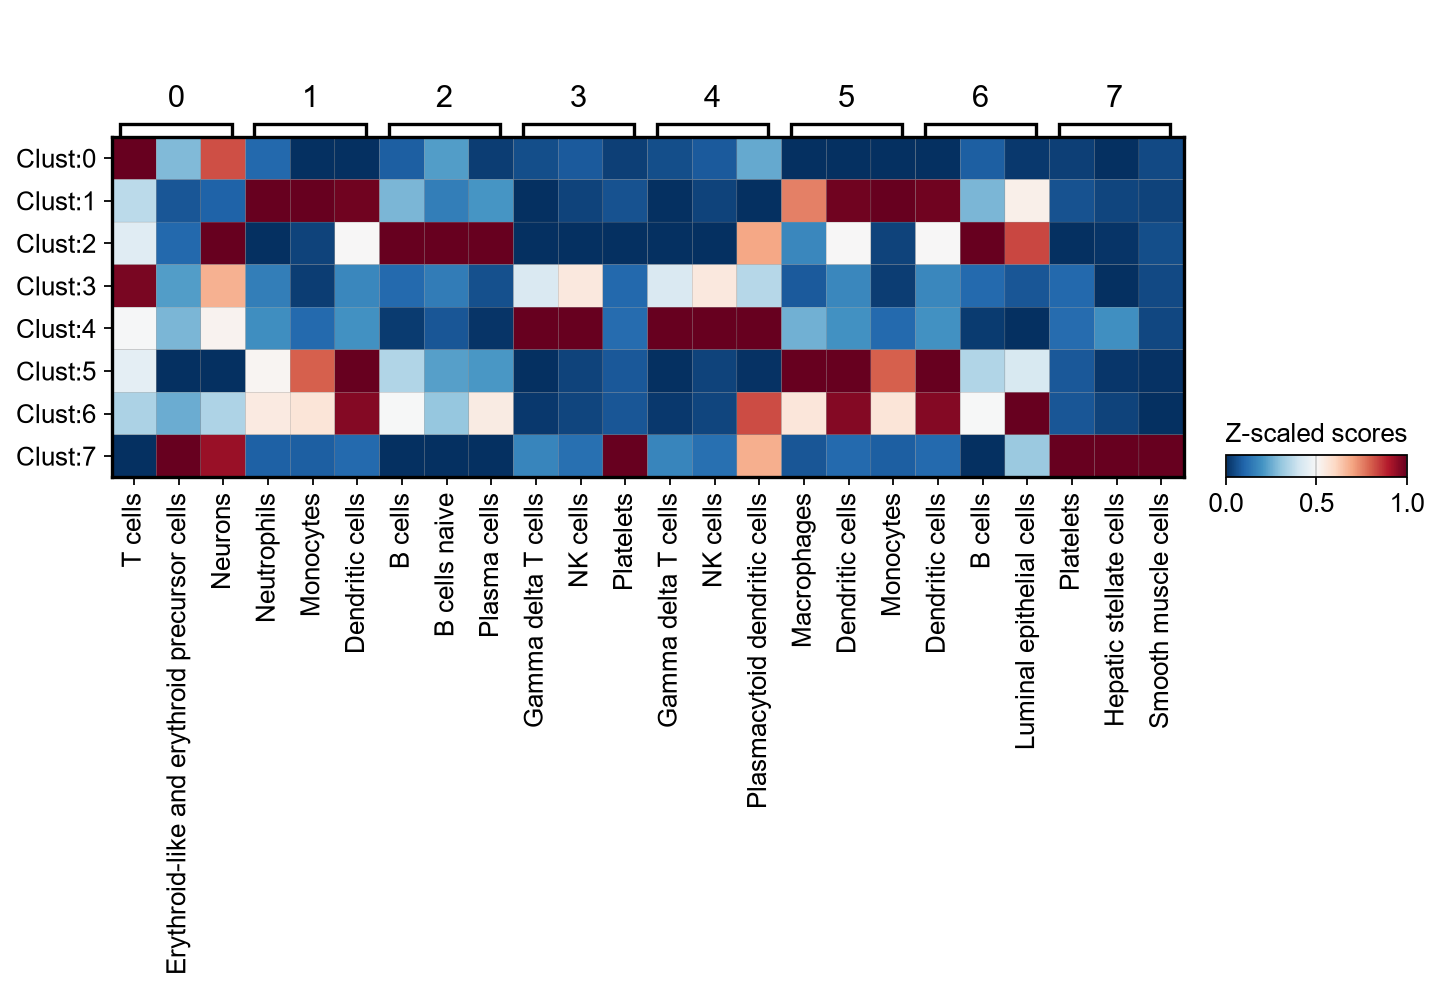

In [78]:
sc.pl.matrixplot(scores_adata,
                 var_names=top_annotations_dict,
                 groupby='leiden',
                 dendrogram=False,
                 standard_scale='var',
                 colorbar_title='Z-scaled scores',
                 cmap='RdBu_r'
                )

## Transcription factor scoring

Gene regulatory networks (GRNs) describe TF-gene interactions - the fundamental unit of a GRN is a TF and its associated target genes, collectively known as a regulon. As such, we can treat each regulon as a gene set.

We score transcription factors based on the expression of their target genes - this is a better representation of TF regulatory activity rather than measuring transcripts of the TFs themselves.

Instead of using leiden cluster labels, we use pre-chosen cell type labels (they've already been analyzed robustly).

This tutorial uses CollecTRI, a curated collection of TFs and their target genes.

In [79]:
collectri = dc.op.collectri(organism='human')
collectri

,source,target,weight,resources,references,sign_decision
0,MYC,TERT,1.0,DoRothEA-A;ExTRI;HTRI;NTNU.Curated;Pavlidis202...,10022128;10491298;10606235;10637317;10723141;1...,PMID
1,SPI1,BGLAP,1.0,ExTRI,10022617,default activation
2,SMAD3,JUN,1.0,ExTRI;NTNU.Curated;TFactS;TRRUST,10022869;12374795,PMID
3,SMAD4,JUN,1.0,ExTRI;NTNU.Curated;TFactS;TRRUST,10022869;12374795,PMID
4,STAT5A,IL2,1.0,ExTRI,10022878;11435608;17182565;17911616;22854263;2...,default activation
...,...,...,...,...,...,...
42985,NFKB,hsa-miR-143-3p,1.0,ExTRI,19472311,default activation
42986,AP1,hsa-miR-206,1.0,ExTRI;GEREDB;NTNU.Curated,19721712,PMID
42987,NFKB,hsa-miR-21,1.0,ExTRI,20813833;22387281,default activation
42988,NFKB,hsa-miR-224-5p,1.0,ExTRI,23474441;23988648,default activation


We can use a univariate linear model (`ulm`) yet again to compute scores

In [81]:
dc.mt.ulm(adata, net=collectri)

In [82]:
scores_adata = dc.pp.get_obsm(adata, key='score_ulm')

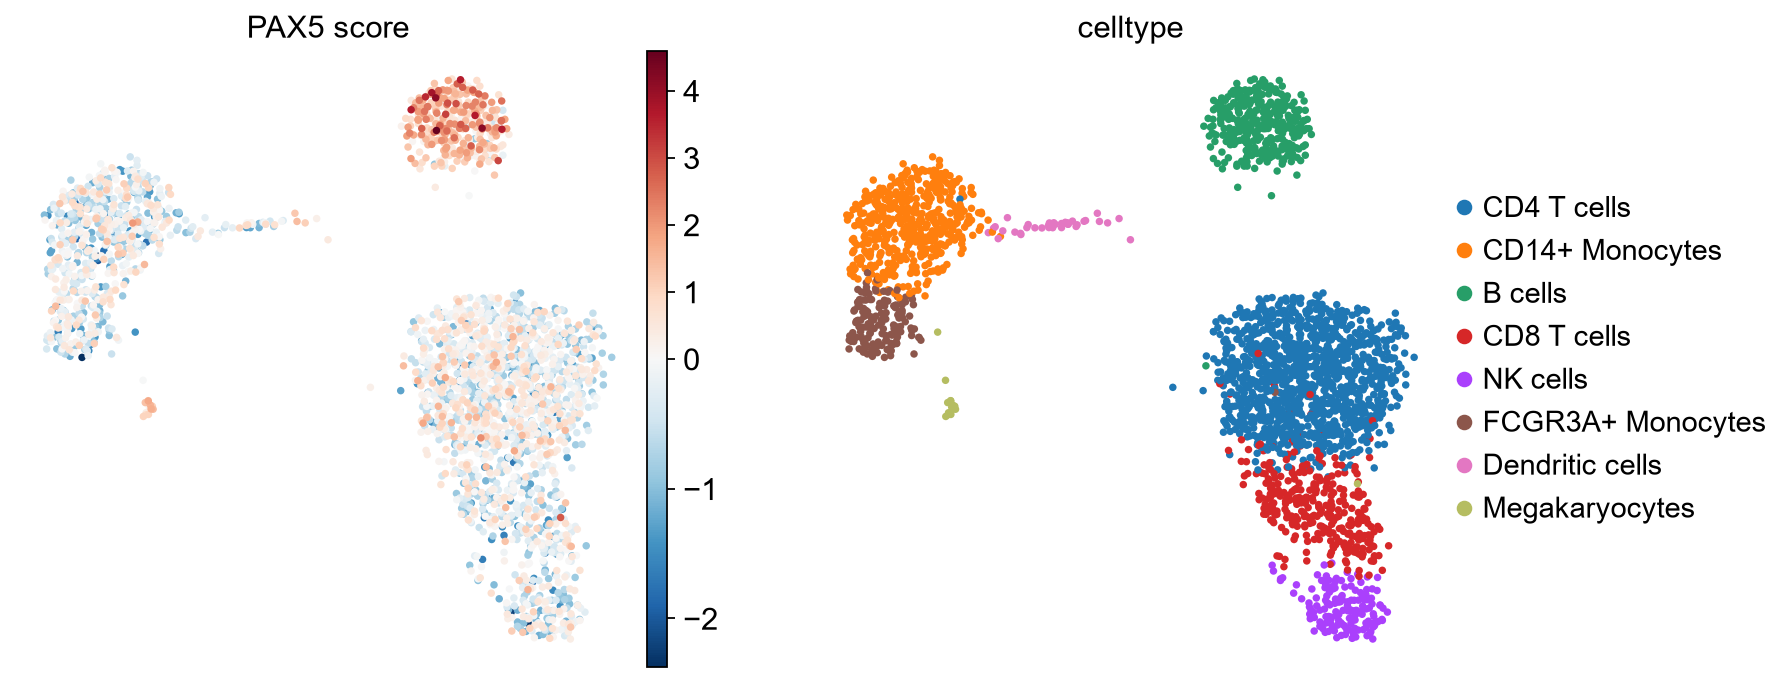

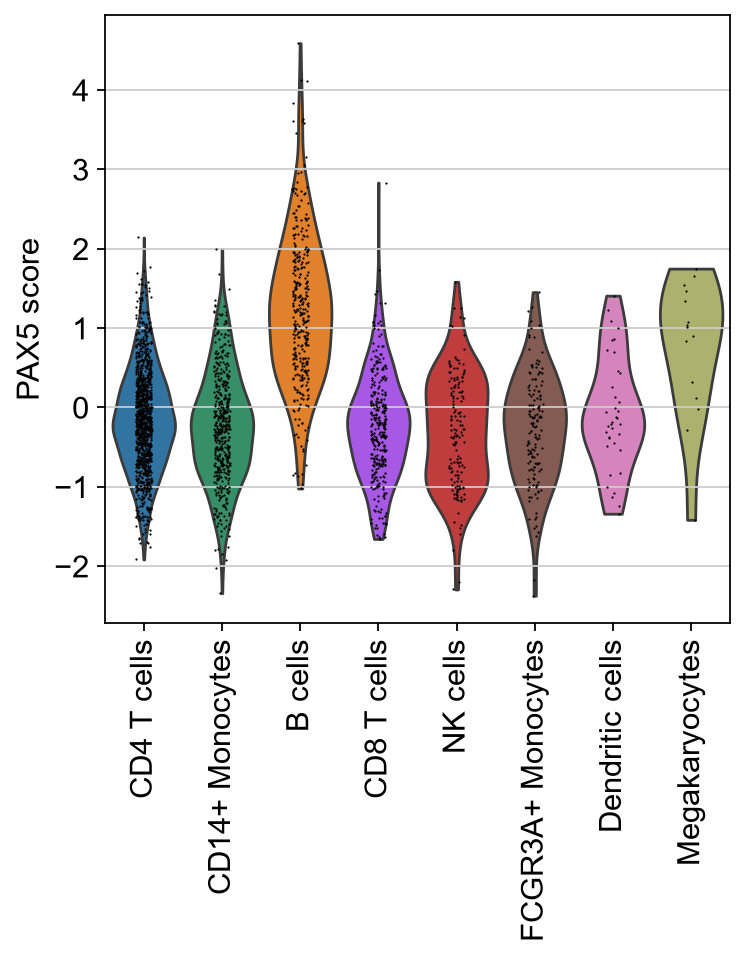

In [83]:
# Example plot with PAX5 TF
tf = 'PAX5'
sc.pl.umap(scores_adata, color=[tf, 'celltype'], cmap='RdBu_r', vcenter=0, title=[f'{tf} score', 'celltype'])
sc.pl.violin(scores_adata, keys=[tf], groupby='celltype', rotation=90, ylabel=f'{tf} score', dodge=False)

From these plots, PAX5 seems to be very active in B cells. However, if we go back to PAX5 expression (NOT the enrichment scores), we see detectable expression in only a few B cells.

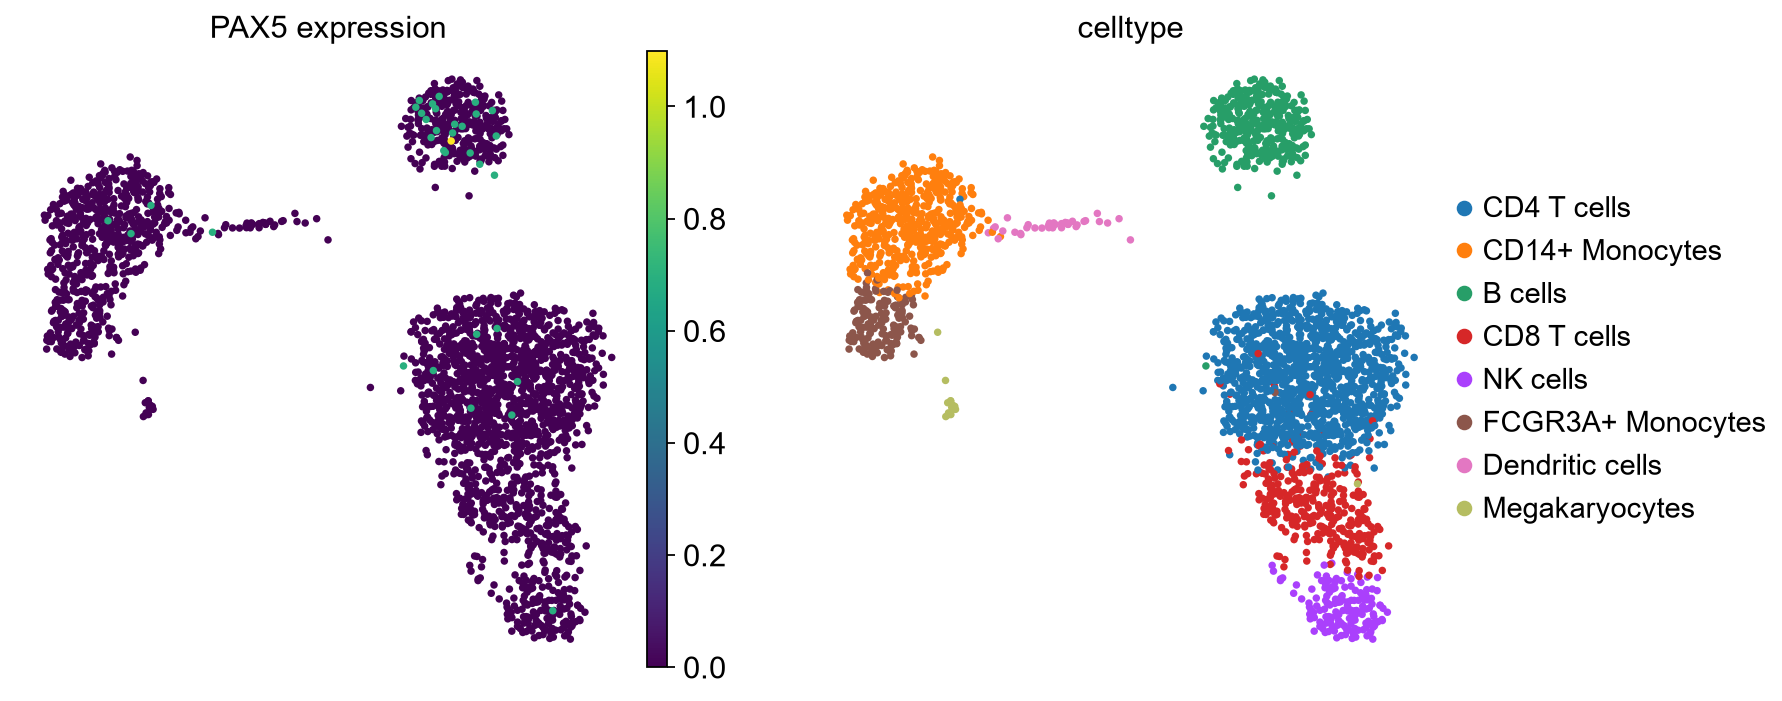

In [84]:
sc.pl.umap(adata, color=[tf, "celltype"], title=[f'{tf} expression', 'celltype'])

We can visualize the top 3 TF markers for each cell type

In [85]:
df = dc.tl.rankby_group(scores_adata, groupby='celltype', reference='rest', method='wilcoxon')
df = df[df['stat'] > 0]
df

,group,reference,name,stat,meanchange,pval,padj
9,CD4 T cells,rest,ZBTB4,30.127245,2.688046,2.131188e-199,1.291500e-197
10,CD4 T cells,rest,MYC,29.420493,2.156232,3.003618e-190,1.654721e-188
25,CD4 T cells,rest,ZBED1,24.328501,1.379326,9.791844e-131,2.282253e-129
29,CD4 T cells,rest,KLF3,23.761016,1.130052,8.453633e-125,1.707634e-123
40,CD4 T cells,rest,ESRRA,20.983889,0.632790,9.204901e-98,1.360529e-96
...,...,...,...,...,...,...,...
4843,Megakaryocytes,rest,NFIA,0.023287,-0.082505,9.814212e-01,9.873940e-01
4844,Megakaryocytes,rest,TCF21,0.021927,-0.375697,9.825059e-01,9.873940e-01
4845,Megakaryocytes,rest,OVOL1,0.013088,-0.360338,9.895573e-01,9.928339e-01
4846,Megakaryocytes,rest,CTBP1,0.004589,0.098506,9.963382e-01,9.963382e-01


In [86]:
n_markers = 3

tf_markers = (
    df.groupby('group')
    .head(n_markers)
    .drop_duplicates('name')
    .groupby('group')['name']
    .apply(lambda x: list(x))
    .to_dict()
)

tf_markers

{'B cells': ['EBF1', 'NOTO', 'CIITA'],
 'CD14+ Monocytes': ['ONECUT1', 'ELF3', 'CEBPE'],
 'CD4 T cells': ['ZBTB4', 'MYC', 'ZBED1'],
 'CD8 T cells': ['KLF13', 'RELB', 'NFKB2'],
 'Dendritic cells': ['RFXAP', 'RFXANK', 'RFX5'],
 'FCGR3A+ Monocytes': ['SIN3A', 'PPARD', 'GATA2'],
 'Megakaryocytes': ['PBX2', 'MEIS1', 'PKNOX1'],
 'NK cells': ['ZGLP1', 'CEBPZ', 'ZNF395']}

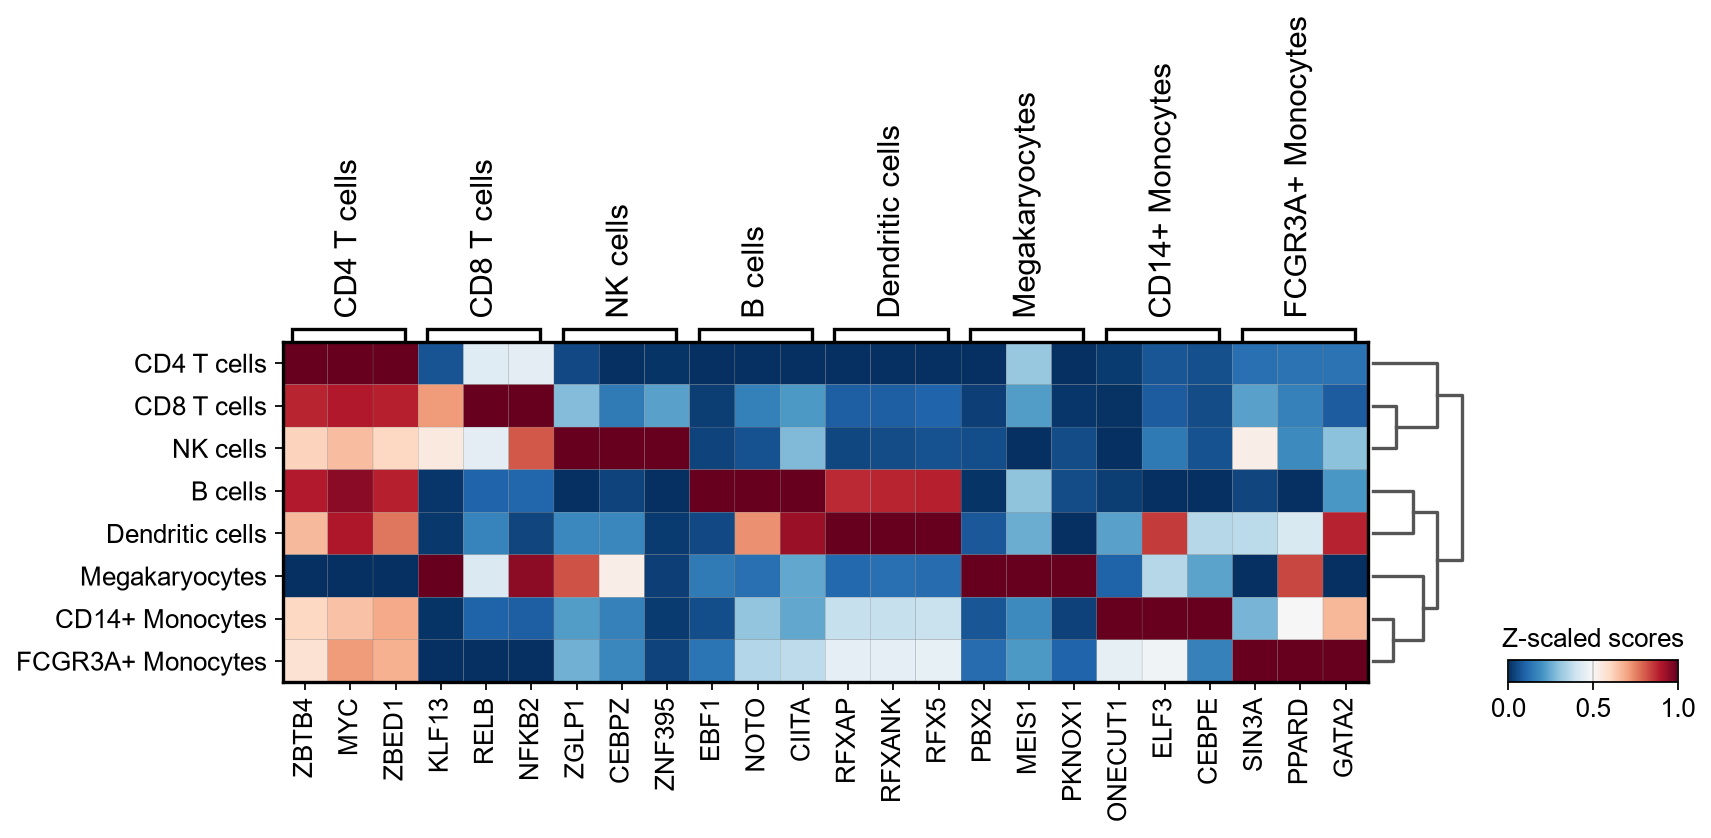

In [87]:
sc.pl.matrixplot(
    scores_adata,
    var_names=tf_markers,
    groupby='celltype',
    dendrogram='True',
    standard_scale='var',
    colorbar_title='Z-scaled scores',
    cmap='RdBu_r'
)

## Pathway enrichment

With Progeny pathways: https://saezlab.github.io/progeny/

In [88]:
progeny = dc.op.progeny(organism='human')
progeny

,source,target,weight,padj
0,Androgen,TMPRSS2,11.490631,2.384806e-47
1,Androgen,NKX3-1,10.622551,2.205102e-44
2,Androgen,MBOAT2,10.472733,4.632376e-44
3,Androgen,KLK2,10.176186,1.944410e-40
4,Androgen,SARG,11.386852,2.790210e-40
...,...,...,...,...
62416,p53,ENPP2,2.771405,4.993215e-02
62417,p53,ARRDC4,3.494328,4.996747e-02
62418,p53,MYO1B,-1.148057,4.997905e-02
62419,p53,CTSC,-1.784693,4.998864e-02


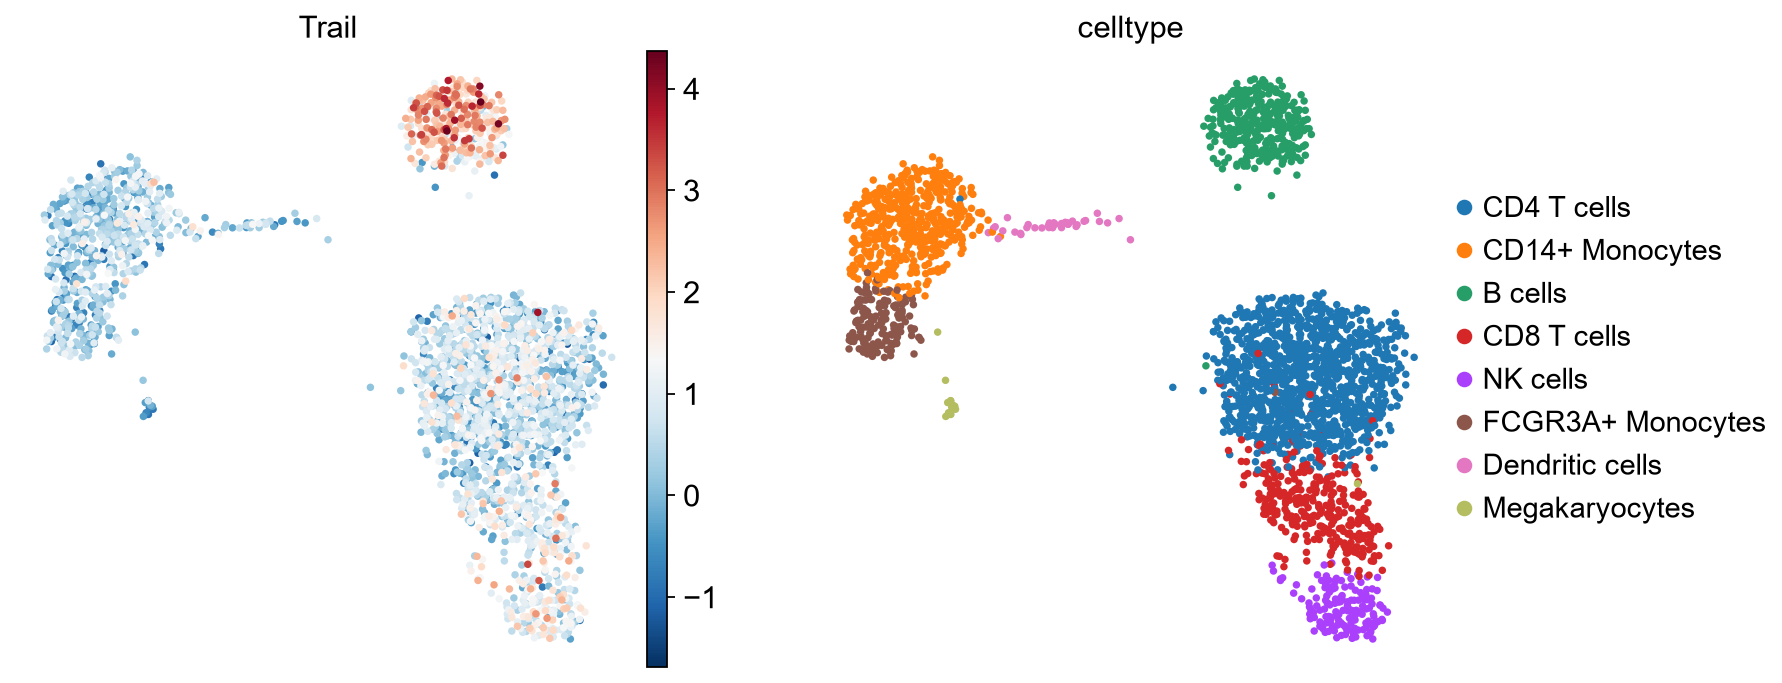

In [90]:
dc.mt.ulm(adata, net=progeny)

scores_adata = dc.pp.get_obsm(adata, key='score_ulm')
sc.pl.umap(scores_adata, color=['Trail', 'celltype'], cmap='RdBu_r')

With Hallmark gene sets instead!

In [100]:
hallmark = dc.op.hallmark(organism="human")
hallmark

,source,target
0,IL2_STAT5_SIGNALING,MAFF
1,COAGULATION,MAFF
2,HYPOXIA,MAFF
3,TNFA_SIGNALING_VIA_NFKB,MAFF
4,COMPLEMENT,MAFF
...,...,...
7313,PANCREAS_BETA_CELLS,STXBP1
7314,PANCREAS_BETA_CELLS,ELP4
7315,PANCREAS_BETA_CELLS,GCG
7316,PANCREAS_BETA_CELLS,PCSK2


In [101]:
dc.mt.ulm(adata, net=hallmark)

scores_adata = dc.pp.get_obsm(adata, key='score_ulm')

df = dc.tl.rankby_group(scores_adata, groupby="celltype", reference="rest", method="t-test_overestim_var")
df = df[df["stat"] > 0]
df

,group,reference,name,stat,meanchange,pval,padj
3,CD4 T cells,rest,MYC_TARGETS_V1,21.490565,1.819335,1.590125e-92,1.987656e-91
8,CD4 T cells,rest,MYC_TARGETS_V2,17.441147,0.553157,4.855032e-64,2.697240e-63
11,CD4 T cells,rest,WNT_BETA_CATENIN_SIGNALING,16.358834,0.366900,6.704730e-57,2.793637e-56
22,CD4 T cells,rest,P53_PATHWAY,11.461240,0.493784,1.378643e-29,2.997051e-29
24,CD4 T cells,rest,E2F_TARGETS,9.503262,0.319374,5.152361e-21,1.030472e-20
...,...,...,...,...,...,...,...
391,Megakaryocytes,rest,IL2_STAT5_SIGNALING,0.436819,0.194693,6.665103e-01,7.934646e-01
392,Megakaryocytes,rest,PI3K_AKT_MTOR_SIGNALING,0.383430,0.163172,7.043131e-01,8.189688e-01
394,Megakaryocytes,rest,INFLAMMATORY_RESPONSE,0.105198,0.044449,9.169803e-01,9.828205e-01
395,Megakaryocytes,rest,WNT_BETA_CATENIN_SIGNALING,0.085780,0.013781,9.324955e-01,9.828205e-01


In [102]:
n_markers = 3
hallmark_markers = (
    df.groupby("group")
    .head(n_markers)
    #.drop_duplicates("name")
    .groupby("group")["name"]
    .apply(lambda x: list(x))
    .to_dict()
)

hallmark_markers

{'B cells': ['KRAS_SIGNALING_DN',
  'ALLOGRAFT_REJECTION',
  'INTERFERON_GAMMA_RESPONSE'],
 'CD14+ Monocytes': ['COMPLEMENT',
  'ANGIOGENESIS',
  'EPITHELIAL_MESENCHYMAL_TRANSITION'],
 'CD4 T cells': ['MYC_TARGETS_V1',
  'MYC_TARGETS_V2',
  'WNT_BETA_CATENIN_SIGNALING'],
 'CD8 T cells': ['ALLOGRAFT_REJECTION',
  'ANDROGEN_RESPONSE',
  'APICAL_JUNCTION'],
 'Dendritic cells': ['OXIDATIVE_PHOSPHORYLATION',
  'FATTY_ACID_METABOLISM',
  'ADIPOGENESIS'],
 'FCGR3A+ Monocytes': ['COMPLEMENT',
  'COAGULATION',
  'INTERFERON_ALPHA_RESPONSE'],
 'Megakaryocytes': ['ANGIOGENESIS', 'COAGULATION', 'APICAL_JUNCTION'],
 'NK cells': ['ALLOGRAFT_REJECTION',
  'INTERFERON_GAMMA_RESPONSE',
  'INTERFERON_ALPHA_RESPONSE']}

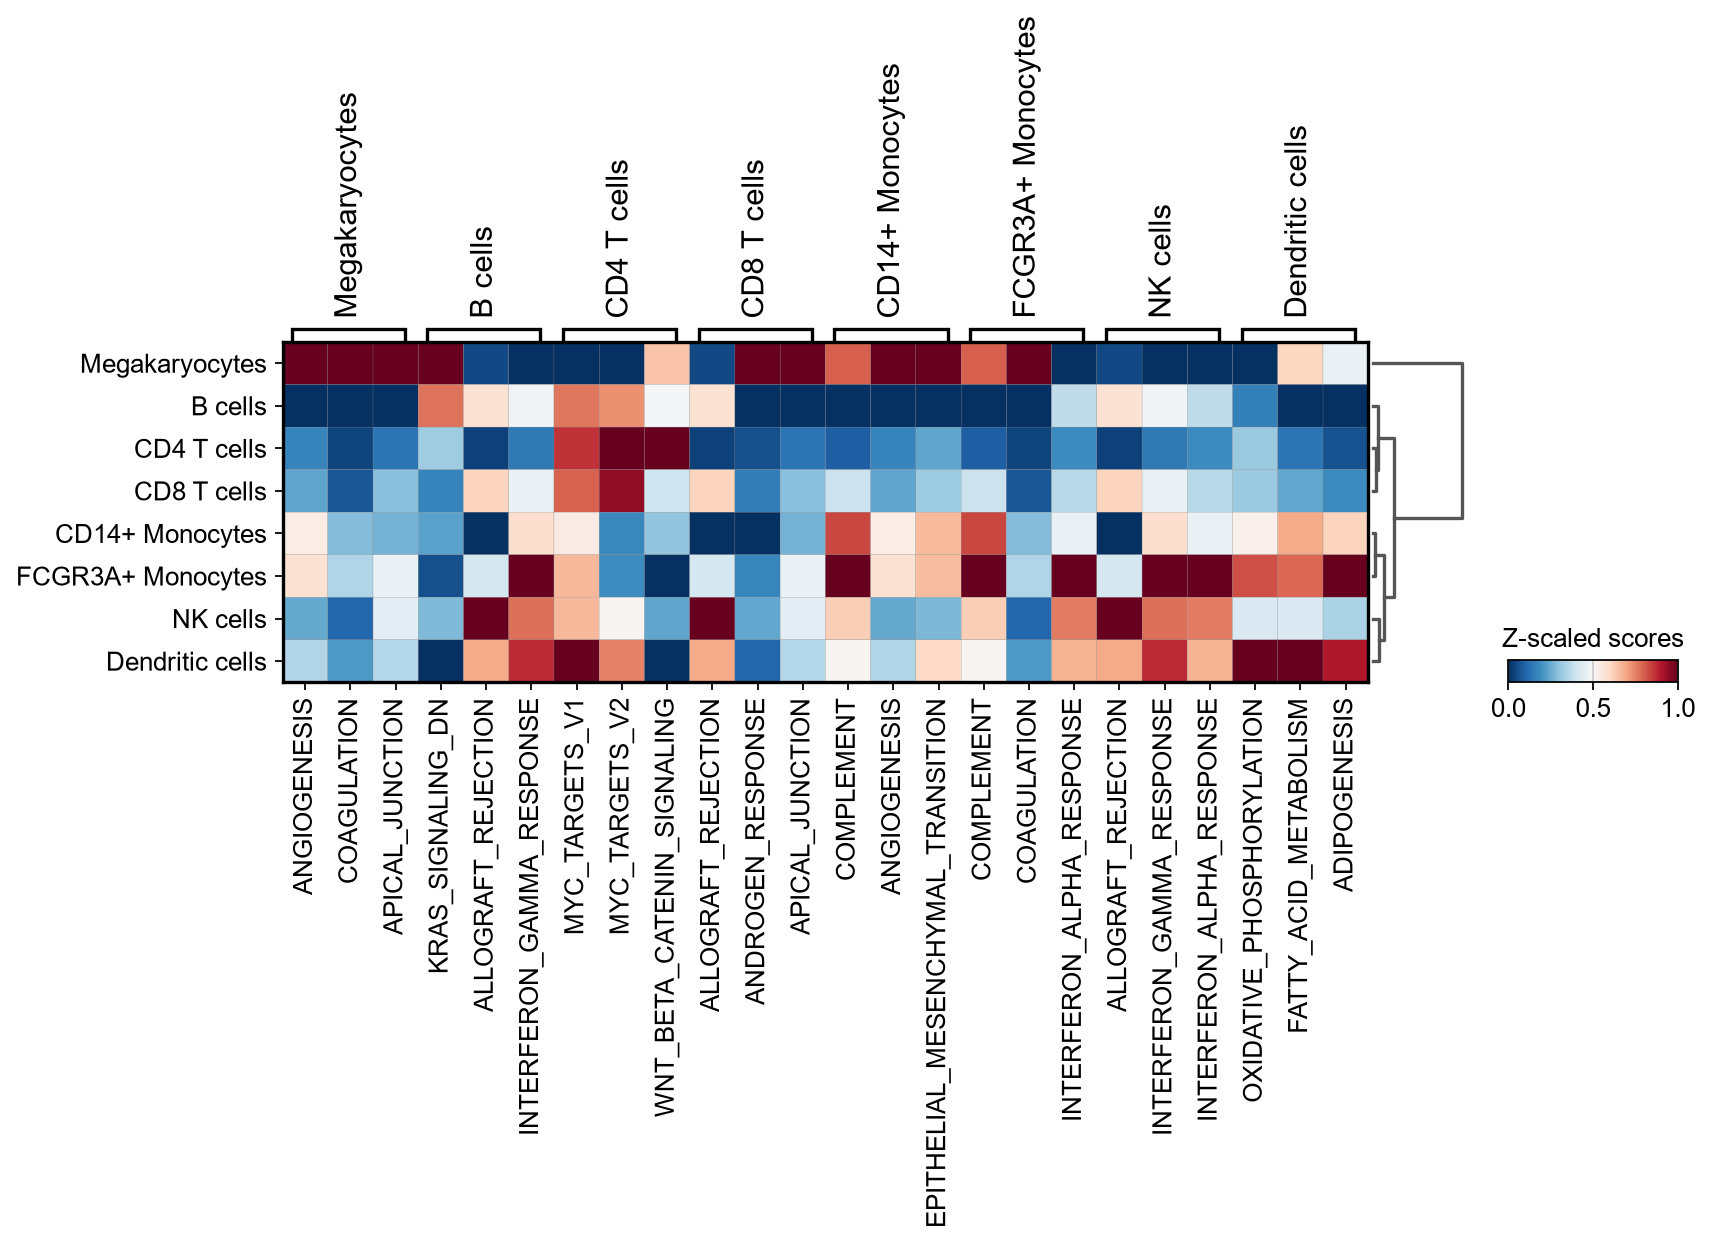

In [104]:
sc.tl.dendrogram(scores_adata, groupby='celltype')
sc.pl.matrixplot(
    adata=scores_adata,
    var_names=hallmark_markers,
    groupby="celltype",
    dendrogram=True,
    standard_scale="var",
    colorbar_title="Z-scaled scores",
    cmap="RdBu_r",
)